In [7]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\Parameter\13. Dust\baru_TES_dust_index_16ppd_numeric.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Dust Cover Index": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("dust3.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude  Dust Cover Index
0        0.5       0.5          0.943976
1        1.5       0.5          0.950453
2        2.5       0.5          0.952210
3        3.5       0.5          0.953829
4        4.5       0.5          0.954724


In [3]:
print(df)

         Longitude  Latitude  Dust Cover Index
0              0.5       0.5          0.850000
1              1.5       0.5          0.850000
2              2.5       0.5          0.850000
3              3.5       0.5          0.850000
4              4.5       0.5          0.850000
...            ...       ...               ...
2026067     2013.5    1003.5          0.936777
2026068     2014.5    1003.5          0.936604
2026069     2015.5    1003.5          0.936467
2026070     2016.5    1003.5          0.940669
2026071     2017.5    1003.5          0.939119

[2026072 rows x 3 columns]


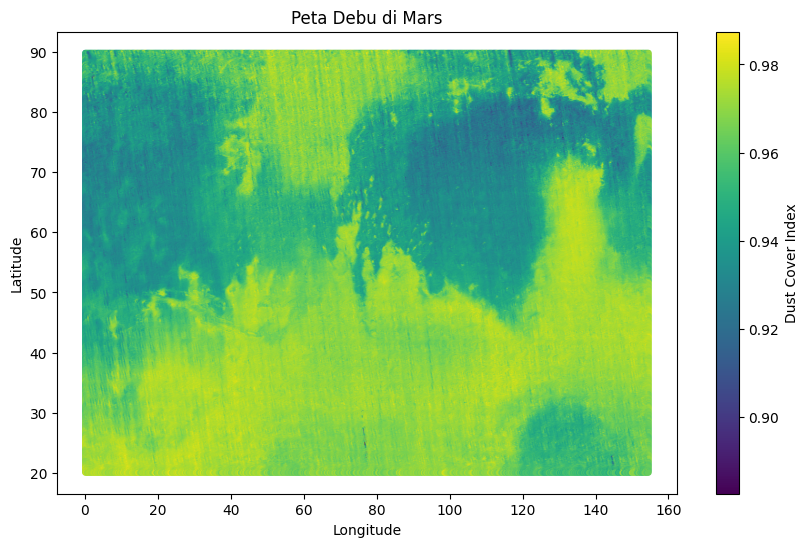

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\13. Dust\dust3.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 2018
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 1004)


# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Dust Cover Index"], cmap="viridis", s=10)
plt.colorbar(label="Dust Cover Index")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Debu di Mars")


plt.show()

In [3]:
counts = df_bersih["Elevation"].value_counts().sort_index()

print(counts)

Elevation
-7721     1
-7673     1
-7662     1
-7646     2
-7632     1
         ..
 20547    1
 20737    1
 21047    1
 21069    1
 21120    1
Name: count, Length: 14301, dtype: int64


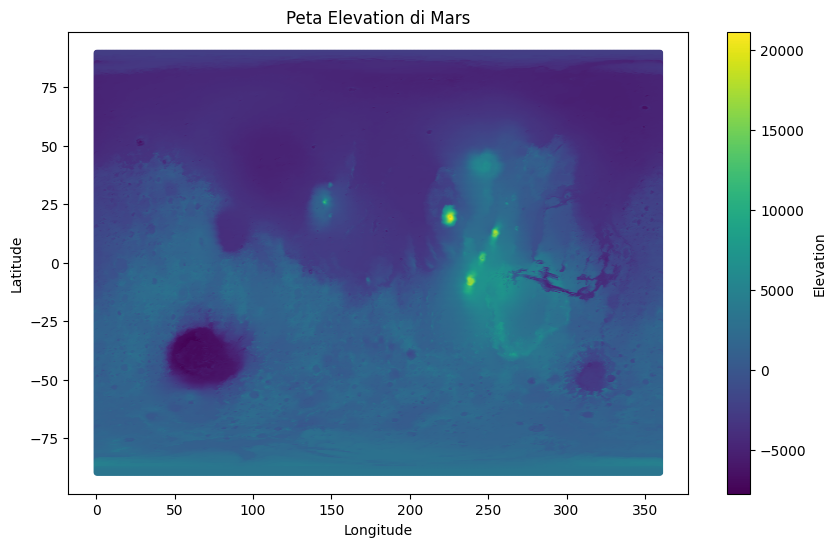

In [4]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Elevation"], cmap="viridis", s=10)
plt.colorbar(label="Elevation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Elevation di Mars")


plt.show()

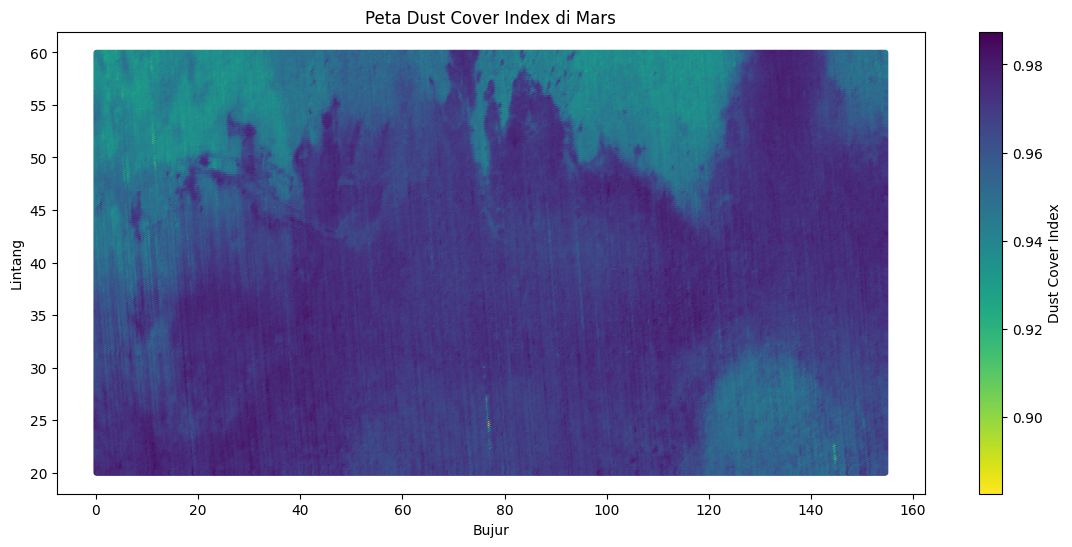

In [9]:
df_nonkutub = df_bersih[(df_bersih["Latitude"] < 60) & (df_bersih["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Dust Cover Index"], cmap="viridis_r", s=10)
plt.colorbar(label="Dust Cover Index")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Dust Cover Index di Mars")
# balik sumbu y
plt.show()